# Cosgrove A549: the cancer-cell stiffness response, finally on a stiffness axis

Three notebooks in, the model's central prediction has still never been tested. v1 and v2 found the
stiff niche and watched tumors build it; v3 established, at some length, that a treatment axis
cannot stand in for a stiffness axis. What was missing the whole time was cancer cells with
stiffness as a controlled variable and everything else held still. This dataset is that.

**Dataset.** Cosgrove, Bounds, Taylor et al. (Gersbach lab), *Science* 2024, "Mechanoresponsive
genomic enhancers potentiate the cellular response to matrix stiffness" (GEO **GSE243763**, bulk
RNA-seq). A549 lung adenocarcinoma cultured on soft (1 kPa) and stiff (50 kPa) polyacrylamide
hydrogels, plus tissue-culture plastic at roughly 1 GPa, 3 biological replicates per condition, RSEM
gene-level quantification.

Why the patient datasets could not do this, in one paragraph: Kim's tumor-versus-normal axis
confounds malignancy with the entire microenvironment, and Maynard's treatment axis (TN/RD/PD)
confounds drug exposure with clonal selection with elapsed time. Neither varies stiffness as a
controlled variable, and no amount of sample size repairs that.

One constraint carries over from the manuscript and limits what even this dataset can say. The model
takes AKT, ERK, and FAK as measured inputs, set from phospho-Westerns rather than transcript levels,
so bulk RNA-seq cannot test the input layer at all; those are kinase activities and not mRNA
abundances. What RNA-seq can test is the model's downstream species, and that is the whole scope of
what follows.

**TL;DR**

- A prespecified score of the four direct model targets is higher in all 3 stiff replicates than in all
  3 soft replicates (stiff - soft = +0.97 oriented z-score units, Welch 95% CI +0.03 to +1.91,
  exact one-sided permutation p = 0.050). No single gene reaches significance at 3 vs 3.
- Separately, the dataset shows a strong and significant YAP/TAZ stiffness response, reproducing the
  source paper through a pathway this model does not contain.
- A549 is KRAS-mutant, so this places the mechanism in lung adenocarcinoma generally rather than in
  the EGFR context specifically.

## 1: Setup — load the DESeq2 stiff-vs-soft results and the signature scores

`ingest_cosgrove.py` has assembled the 9 A549 RSEM files, run PyDESeq2 on stiff (50 kPa) against
soft (1 kPa), and written counts, TPM, and per-signature scores. `check_model_targets.py` uses the
six soft/stiff biological replicates to calculate the prespecified oriented target score. Positive
log2FC means up on stiff throughout. This notebook loads those outputs and reasons about them.

If the files are missing, run `ingest_cosgrove.py` first, from the environment carrying pydeseq2 and
pyensembl.

In [1]:
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from IPython.display import SVG, display
from pathlib import Path
import os

In [2]:
d = Path.cwd()
while not (d / 'workflow').is_dir() and d != d.parent:
    d = d.parent
os.chdir(d)
print('repo root:', d)

RES = Path('results_cosgrove')
de = pd.read_csv(RES / 'deseq2_stiff_vs_soft.csv')
sig = pd.read_csv(RES / 'signature_summary.csv')
sample_scores = pd.read_csv(RES / 'model_target_scores_by_sample.csv')
score_stats = pd.read_csv(RES / 'model_target_score_summary.csv')
print(f'DESeq2 table: {de.shape[0]:,} genes;  '
      f"{(de['padj'] < 0.05).sum():,} significant at padj<0.05")
plt.rcParams.update({'figure.dpi': 110, 'axes.spines.top': False, 'axes.spines.right': False})

repo root: C:\Users\olesk\repos\lung_stiffness_RNAseq
DESeq2 table: 19,976 genes;  235 significant at padj<0.05


## 2: What this assay can legitimately test

The model's wiring, from `cell_cycle_death_model.py`: three independent inputs, AKT, ERK, and FAK,
each set per (stiffness, drug) condition, feeding the cell-cycle and apoptosis ODEs. The rate laws
that matter here:

| input | acts on | rate law | downstream gene | predicted on stiff |
|---|---|---|---|---|
| AKT, ERK | CycD synthesis | `ks_CycD_AKT`, `ks_CycD_ERK` | CCND1 | UP |
| AKT, ERK | Myc synthesis | `ks_Myc_AKT`, `ks_Myc_ERK` | MYC | UP |
| FAK | Skp2 synthesis | `ks_Skp2_FAK` | SKP2 | UP |
| FAK | p21 *repression* | `ks_p21` (FAK in the denominator) | CDKN1A | DOWN |

Stiff carries higher AKT, ERK, and FAK than soft: the stiff DMSO input is `[1,1,1]` against soft
DMSO's `[0.6,1,0.4]`. Those inputs are phospho-regulated kinase activities rather than transcript
levels, so RNA-seq has no access to them, since a gene's mRNA abundance says nothing about whether
its protein is phosphorylated. The downstream targets in the table are transcriptionally produced,
which makes them the part of the model this assay is entitled to evaluate. Everything past this
point stays inside that boundary.

In [3]:
# the model's downstream targets and their predicted direction on stiff (from the ODE rate laws)
TARGETS = {  # gene: (predicted_direction, driving_input)
    'CCND1':  ('UP',   'AKT,ERK'),
    'MYC':    ('UP',   'AKT,ERK'),
    'SKP2':   ('UP',   'FAK'),
    'CDKN1A': ('DOWN', 'FAK'),
}
SUPPORT = {  # downstream E2F program (two steps below CycD); weaker, expected
    'E2F1':  ('UP', 'CycD->Rb->E2F'),
    'CCNE1': ('UP', 'E2F target'),
}

def lookup(gene):
    r = de[de['symbol'] == gene]
    return None if r.empty else r.iloc[0]

rows = []
for gene, (pred, drv) in {**TARGETS, **SUPPORT}.items():
    r = lookup(gene)
    if r is None:
        rows.append({'gene': gene, 'set': 'primary' if gene in TARGETS else 'support',
                     'pred': pred, 'driver': drv, 'log2FC': np.nan, 'padj': np.nan, 'pctile': np.nan})
        continue
    # percentile against the whole transcriptome: an LFC is hard to read on its own,
    # and "88th percentile of all genes" says how unusual the shift actually is
    pct = (de['log2FoldChange'] < r['log2FoldChange']).mean() * 100
    rows.append({'gene': gene, 'set': 'primary' if gene in TARGETS else 'support',
                 'pred': pred, 'driver': drv, 'log2FC': round(r['log2FoldChange'], 3),
                 'padj': r['padj'], 'pctile': round(pct, 1)})
tgt = pd.DataFrame(rows)
print(tgt.to_string(index=False))

  gene     set pred        driver  log2FC     padj  pctile
 CCND1 primary   UP       AKT,ERK   0.391 0.080407    88.5
   MYC primary   UP       AKT,ERK   0.126 0.523304    69.1
  SKP2 primary   UP           FAK   0.269 0.397548    82.4
CDKN1A primary DOWN           FAK  -0.085 0.748500    37.6
  E2F1 support   UP CycD->Rb->E2F   0.180 0.609931    74.8
 CCNE1 support   UP    E2F target   0.232 0.403443    79.3


**Read-out.** Every model-predicted target moves the way it was predicted to move: CCND1, MYC, and
SKP2 up, CDKN1A down, with the E2F program (E2F1, CCNE1) following a step behind.

The percentiles say how far, which a bare log2FC does not. CCND1 sits around the 88th percentile of
all genes in the experiment, SKP2 around the 82nd, and MYC around the 69th, so these are shifted
relative to the rest of the transcriptome and not merely shifted away from zero. CDKN1A is the weak
one, just below center, which makes the p21-repression arm directionally correct and not much more
than that. Better to say so here than to let the 4/4 concordance in the next section quietly paper
over it.

What the pattern has going for it is that it follows the model's wiring rather than a general "cells
are busier on stiff substrates" story. The two genes driven by AKT and ERK, the gene driven by FAK,
and the gene repressed by FAK all land where their rate laws put them.

## 3: Do biological replicates shift in the model-predicted direction?

The inferential unit must be the biological replicate, not the gene. Treating four correlated target
genes as independent Bernoulli trials understates uncertainty, while comparing their LFCs with all
genome-wide LFCs by Mann-Whitney U does not test replication across the 3 soft and 3 stiff samples.

The primary analysis therefore makes one prespecified score per sample:

1. Restrict to the six hydrogel samples and transform each direct target as log2(TPM + 1).
2. Z-score each gene across those six samples and multiply by its prespecified direction (+1 for
   CCND1/MYC/SKP2, -1 for CDKN1A).
3. Average the four oriented values, yielding one primary score per biological replicate.

The reported effect is the stiff-minus-soft mean difference, with a Welch 95% confidence interval
and an exact one-sided label-permutation p-value over all 20 possible 3-vs-3 allocations. E2F1 and
CCNE1 remain a separately labeled descriptive support score; they are not added to the primary test.

In [ ]:
primary = score_stats.loc[score_stats['score'] == 'primary_oriented_score'].iloc[0]
print(sample_scores[['sample_id', 'condition', 'rep', 'primary_oriented_score']].to_string(index=False))
print(f"\nstiff - soft = {primary['stiff_minus_soft']:+.3f}")
print(f"Welch 95% CI [{primary['welch_95ci_low']:+.3f}, {primary['welch_95ci_high']:+.3f}]")
print(f"Hedges g = {primary['hedges_g']:+.3f}")
print(f"exact one-sided permutation p = {primary['exact_permutation_p_one_sided']:.4f}")
display(SVG(filename=str(RES / 'model_target_score_by_replicate.svg')))

**Read-out.** All three stiff replicates score above all three soft replicates. The prespecified
primary score differs by +0.97 oriented z-score units (Welch 95% CI +0.03 to +1.91; Hedges' g
+2.42). The exact one-sided permutation p-value is 0.050, the smallest possible value with only 20
ways to allocate six samples into groups of three.

This is stronger descriptive separation than the gene-level adjusted p-values convey, but the
interval is wide and the exact p-value sits at the design's resolution limit. The appropriate claim
is therefore that the replicate-level score supports a stiffness-associated shift in the predicted
direction, not that correlated genes supply multiple independent confirmations.

E2F1 and CCNE1 also move in the predicted direction, but they are downstream support rather than
direct input-driven targets. Their score is retained descriptively and does not strengthen the
primary p-value.

## 4: Signature-level view, and the separate YAP/TAZ response

Zooming out from individual genes to the node signatures (z-scored log2 TPM across soft, stiff, and
TCP).

There are two stories in this figure and they belong to different papers. The model's nodes
(proliferation, CDK4/6) trend up on stiff, but modestly. The YAP/TAZ signature, which is not a node
in this model at all, is the one carrying a large and significant LFC, reproducing the source
paper's headline. Both get shown and both get kept separate, because the tempting move is to let the
strong YAP result lend its significance to the weaker model result, and the two are not testing the
same thing.

         signature  n_genes  soft_score  stiff_score  stiff_minus_soft  mean_LFC_stiff_vs_soft  median_padj      predicted
fak_focal_adhesion        8      -0.748        0.131             0.879                   0.231      0.33500    UP on stiff
     pi3k_akt_axis        6      -0.733        0.307             1.040                   0.119      0.70300    UP on stiff
     proliferation        6      -0.539        0.136             0.675                   0.163      0.50400    UP on stiff
   cdk46_cellcycle        7      -0.620        0.530             1.150                   0.118      0.72700    UP on stiff
   yap_taz_targets        7      -1.039        0.031             1.070                   0.581      0.00166 (readout/ctrl)
    stiffening_ecm        6      -0.256        0.589             0.844                   1.459      0.38200 (readout/ctrl)


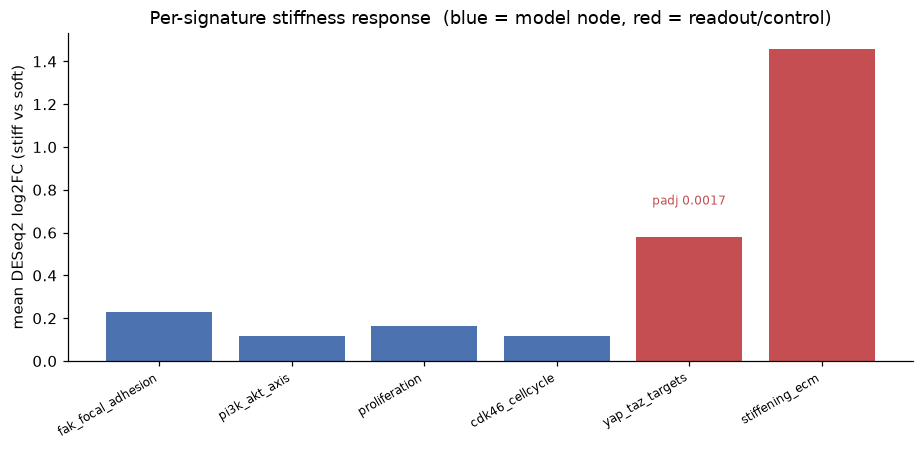

In [5]:
# DESeq2 mean LFC + median padj per signature (already computed by the ingest)
show = sig.copy()
print(show.to_string(index=False))

# bar of mean LFC (stiff vs soft) per signature, model nodes vs readouts/controls flagged
order = ['fak_focal_adhesion','pi3k_akt_axis','proliferation','cdk46_cellcycle',
         'yap_taz_targets','stiffening_ecm']
order = [s for s in order if s in set(show['signature'])]
vals = [show.loc[show.signature==s, 'mean_LFC_stiff_vs_soft'].iloc[0] for s in order]
model_node = [s in ('fak_focal_adhesion','pi3k_akt_axis','proliferation','cdk46_cellcycle') for s in order]
colors = ['#4C72B0' if m else '#C44E52' for m in model_node]
fig, ax = plt.subplots(figsize=(8.5, 4.2))
ax.bar(range(len(order)), vals, color=colors)
ax.axhline(0, color='grey', lw=.7)
ax.set_xticks(range(len(order)))
ax.set_xticklabels(order, rotation=30, ha='right', fontsize=8)
ax.set_ylabel('mean DESeq2 log2FC (stiff vs soft)')
ax.set_title('Per-signature stiffness response  (blue = model node, red = readout/control)')
# annotate YAP significance
if 'yap_taz_targets' in order:
    yi = order.index('yap_taz_targets')
    ax.annotate('padj 0.0017', xy=(yi, vals[yi]), xytext=(yi, vals[yi]+0.15),
                ha='center', fontsize=8, color='#C44E52')
plt.tight_layout(); plt.show()

**Read-out.** The model's nodes, in blue, all trend positive on stiff with modest mean LFCs of about
0.12 to 0.23 and non-significant median padj. That matches the per-gene picture from section 2, and
it is also roughly what the model's own structure predicts: the input kinases are phospho-regulated,
so there is no particular reason their transcripts should move much, and a signature built partly
out of those transcripts will move less than the downstream targets do.

The standout is `yap_taz_targets` at LFC +0.58, padj 0.0017. That is a strong, significant stiffness
response, it reproduces the source paper, and it is good evidence that these cells are mechanosensing
vigorously. It is not evidence for this model, which does not route through YAP.

## 5: Conclusions

In A549 lung adenocarcinoma cells, a clean soft-versus-stiff contrast shifts the model's downstream
cell-cycle targets in the predicted direction: CCND1, MYC, and SKP2 up and CDKN1A down. A
prespecified replicate-level score is higher in all 3 stiff samples than in all 3 soft samples
(stiff - soft +0.97, Welch 95% CI +0.03 to +1.91, exact one-sided permutation p = 0.050). No
single gene is significant at 3 vs 3, and the E2F1/CCNE1 support set is reported separately rather
than pooled into the primary inference. CCND1 is the standout at the 88th
percentile genome-wide, which is an interesting place for it to land, since cyclin D–CDK4/6 is the
node the model's therapeutic lever acts on.

Alongside that sits a strong and significant YAP/TAZ stiffness response (padj 0.0017), reproducing
the source paper through a pathway this model does not contain.

The model's kinase inputs (AKT, ERK, FAK) were set from Western data rather than transcripts,
because they are phospho-regulated, so the directional consistency of the downstream targets is the
appropriate evidence here and the input genes are not.

**The caveat, and it is a real one.** A549 is KRAS-mutant. This places the mechanism in lung
adenocarcinoma, not in the EGFR context the model is ultimately about, and that gap is not small.
The literature points the same way (Martino et al. report YAP, CTGF, CYR61, and Ki67 rising with
stiffness in PC9 and HCC827 hydrogel data) but through targeted qPCR and protein rather than a
transcriptome-wide contrast, so it corroborates the direction without closing the gap.

**Where this leaves the project.** Kim and Tsukui showed that tumors can construct the stiff niche,
with CAFs activating the CTHRC1⁺ program in patient tissue. Maynard's treatment axis turned out to be
orthogonal to stiffness, and its mechano-signatures did not survive aggregation to the patient. This
dataset supplies the piece none of them could: given an actual stiffness contrast, cancer cells do
respond, and they respond in the cell-cycle program the model predicts. Both halves of the model now
have evidence behind them, in KRAS-mutant cells and at the level of a gene set rather than a gene,
which is considerably less than the whole claim and considerably more than the project started with.